In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy

# Przygotowanie danych

### Pobranie danych

In [2]:
signal = np.loadtxt("assets/signal.csv")

### Wygenerowanie danych

In [3]:
import impuls_simulator
B=30
fs=25000
varsize=25000
fmod=30
f_center=6000
bandwidth=500
shift=0
sigma = 5
signal = impuls_simulator.gen_signal(B,fs,varsize,fmod,f_center,bandwidth,shift,sigma)

## Szereg w czasie

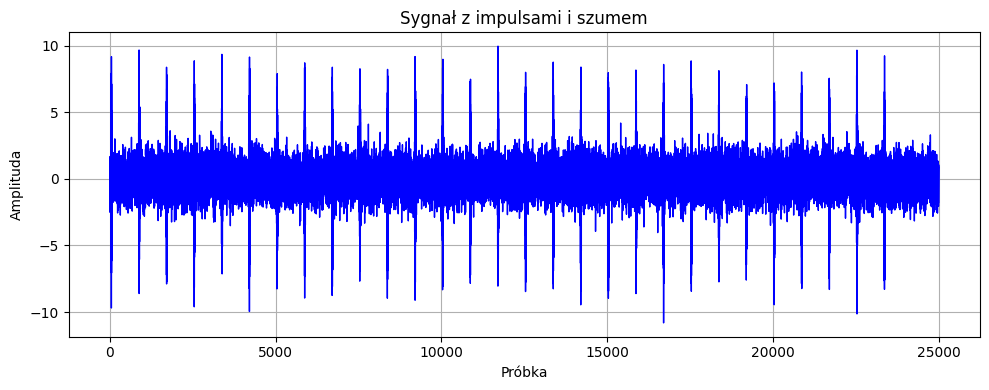

In [4]:
plt.figure(figsize=(10, 4))
plt.plot(signal, color='blue', linewidth=1)
plt.title("Sygnał z impulsami i szumem")
plt.xlabel("Próbka")
plt.ylabel("Amplituda")
plt.grid(True)
plt.tight_layout()
plt.show()

## Spektrogram

### Obliczenie krótkoczasowej transformaty Fouriera

In [5]:
fs = 25000
array_freq, array_tt, matrix_Zxx = scipy.signal.stft(signal, fs = fs, window = 'hann')
Zxx = np.abs(matrix_Zxx)

### Wyrysowanie wykresu

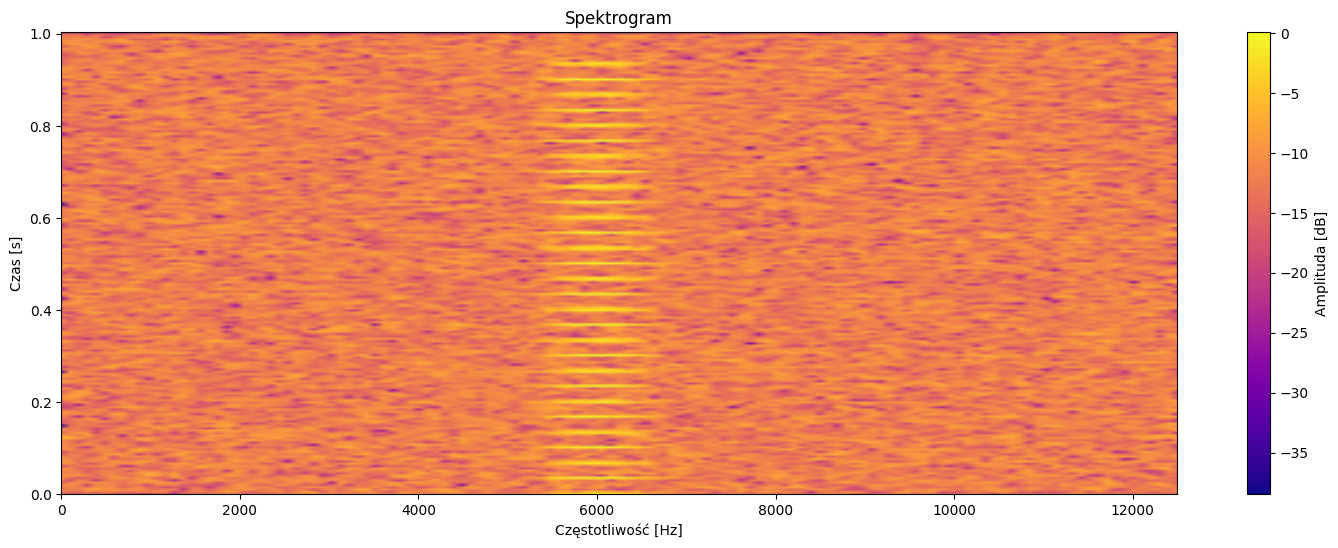

In [6]:

plt.figure(figsize=(18, 6))
plt.pcolormesh(array_freq, array_tt, 10*np.log10(Zxx.T), shading='gouraud', cmap='plasma')
plt.xlabel('Częstotliwość [Hz]')
plt.ylabel('Czas [s]')
plt.title('Spektrogram')
plt.colorbar(label='Amplituda [dB]')
plt.show()

# Selektory

In [7]:
import ifb_selectors as selector

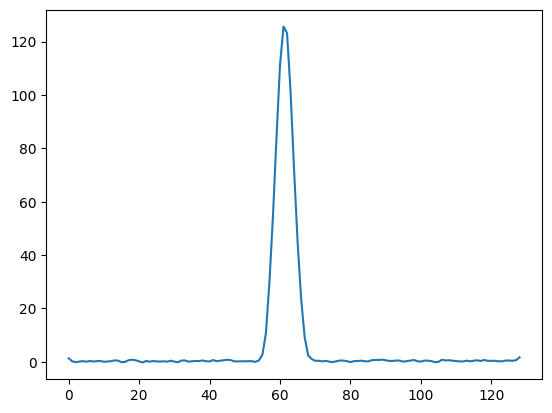

In [8]:
sk_results = selector.SK(Zxx)
plt.plot(sk_results)

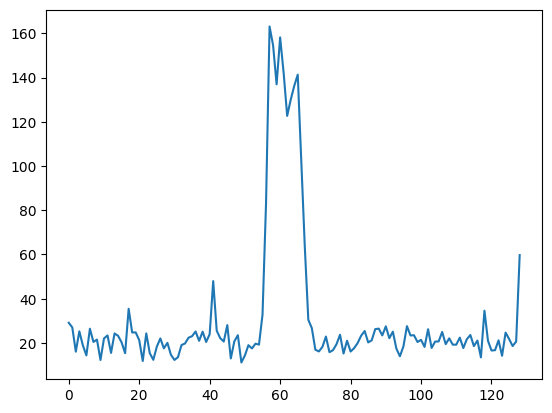

In [9]:
jb_results = selector.JB(Zxx)
plt.plot(jb_results)

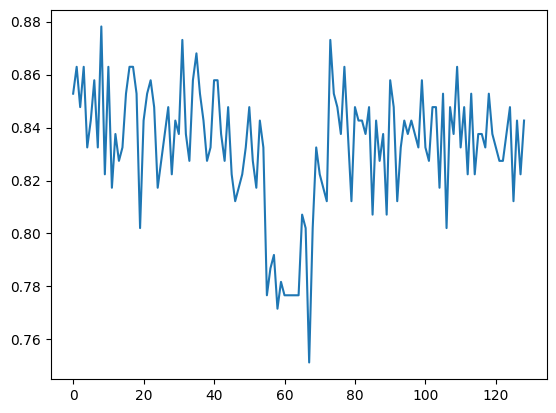

In [10]:
kss_results = selector.KSS(Zxx)
plt.plot(1/kss_results)

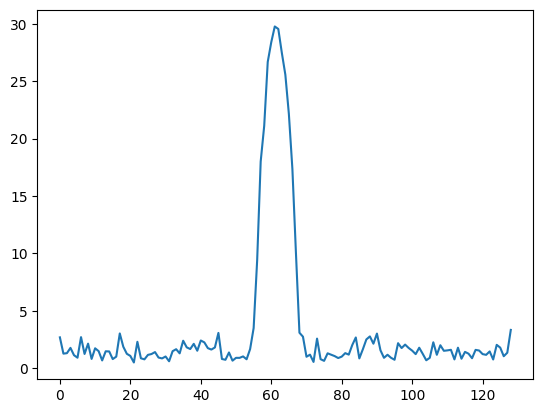

In [11]:
ad_results = selector.AD(Zxx)
plt.plot(ad_results)

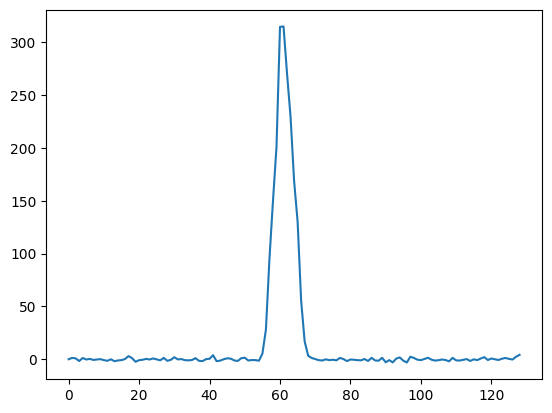

In [12]:
cvs_results = selector.cvs(Zxx)
plt.plot(cvs_results)

## Faktyczne obliczenie wszystkich selektorów


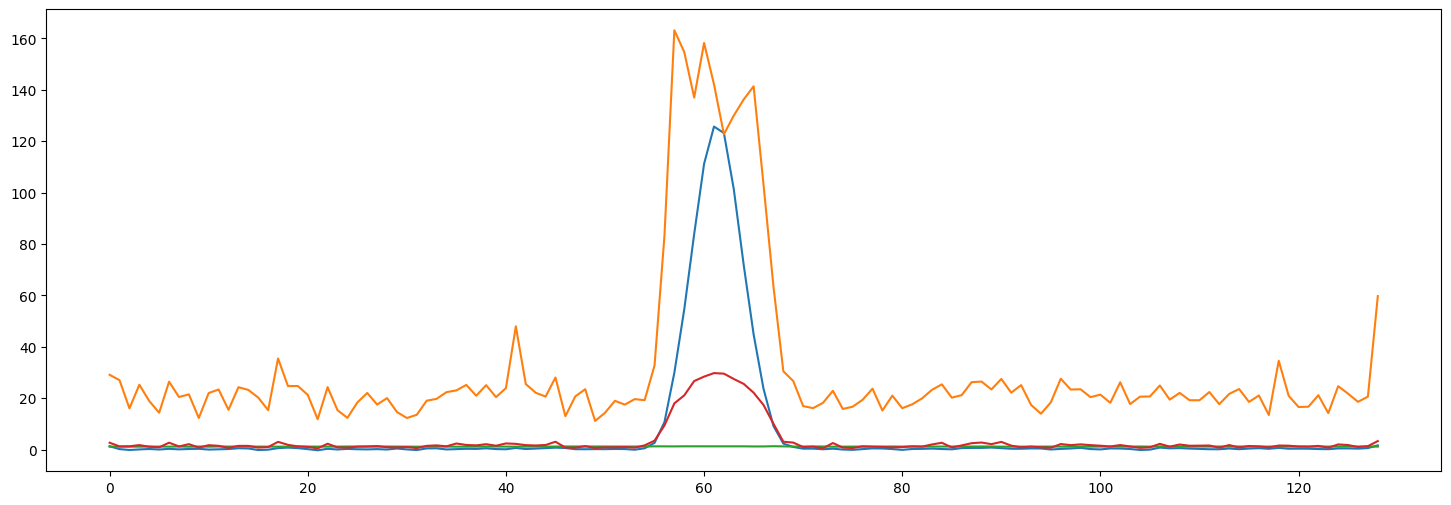

In [13]:
sk_results = selector.SK(Zxx)
jb_results = selector.JB(Zxx)
kss_results = selector.KSS(Zxx)
ad_results = selector.AD(Zxx)

plt.figure(figsize=(18, 6))
plt.plot(sk_results)
plt.plot(jb_results)
plt.plot(kss_results)
plt.plot(ad_results)